In [702]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [703]:
df = pd.read_csv('churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [704]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [705]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [706]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  str    
 2   Gender           10000 non-null  str    
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), str(2)
memory usage: 966.1 KB


<Axes: >

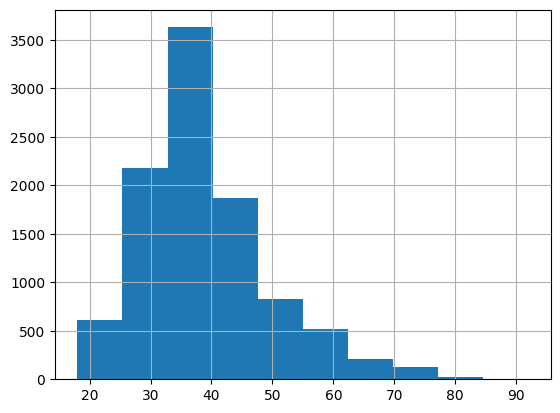

In [707]:
df.duplicated().sum()
df.groupby('Geography')['Exited'].mean()
df['Age'].hist()

In [708]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [709]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [710]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [711]:
df['Exited'].value_counts(normalize=True)
df.groupby('Geography')['Exited'].mean()


Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [712]:
df.groupby('Geography')['Exited'].mean()




Geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: Exited, dtype: float64

In [713]:
df.groupby('Age')['Exited'].mean()


Age
18    0.090909
19    0.037037
20    0.050000
21    0.056604
22    0.142857
        ...   
83    0.000000
84    0.500000
85    0.000000
88    0.000000
92    0.000000
Name: Exited, Length: 70, dtype: float64

In [714]:
df.groupby('Gender')['Exited'].mean()


Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64

In [715]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True, dtype=int)
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [716]:
df.corr()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
CreditScore,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094,0.005538,0.004780,-0.002857
Age,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323,0.046897,-0.001685,-0.027544
Tenure,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001,-0.000567,0.003868,0.014733
Balance,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533,0.401110,-0.134892,0.012087
NumOfProducts,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820,-0.010419,0.009039,-0.021859
HasCrCard,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138,0.010577,-0.013480,0.005766
IsActiveMember,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128,-0.020486,0.016732,0.022544
EstimatedSalary,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097,0.010297,-0.006482,-0.008112
Exited,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000,0.173488,-0.052667,-0.106512
Geography_Germany,0.005538,0.046897,-0.000567,0.401110,-0.010419,0.010577,-0.020486,0.010297,0.173488,1.000000,-0.332084,-0.024628


In [717]:
df.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

In [718]:
df['Balance'].describe()

count     10000.000000
mean      76485.889288
std       62397.405202
min           0.000000
25%           0.000000
50%       97198.540000
75%      127644.240000
max      250898.090000
Name: Balance, dtype: float64

In [719]:
df[['CreditScore','Exited']].corr()

,CreditScore,Exited
CreditScore,1.000000,-0.027094
Exited,-0.027094,1.000000


In [720]:
df ['age_group']= pd.cut(df['Age'], bins=[10,30,50,100], labels=['0','1','2'])

In [721]:
df.groupby(df['Balance'] > 0)['Exited'].mean()
df['has_balance'] = (df['Balance'] > 0).astype(int)
df.groupby('IsActiveMember')['Exited'].mean()

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

In [722]:
X = df.drop('Exited', axis=1)
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train, y_train

(array([[ 0.35649971, -0.6557859 ,  0.34567966, ...,  0.91324755,
          0.12557238, -1.31969839],
        [-0.20389777,  0.29493847, -0.3483691 , ...,  0.91324755,
          0.12557238,  0.7577489 ],
        [-0.96147213, -1.41636539, -0.69539349, ...,  0.91324755,
         -1.63994433,  0.7577489 ],
        ...,
        [ 0.86500853, -0.08535128, -1.38944225, ..., -1.09499335,
          0.12557238, -1.31969839],
        [ 0.15932282,  0.3900109 ,  1.03972843, ...,  0.91324755,
          0.12557238,  0.7577489 ],
        [ 0.47065475,  1.15059039, -1.38944225, ...,  0.91324755,
          1.89108908,  0.7577489 ]], shape=(8000, 13)),
 9254    0
 1561    0
 1670    1
 6087    1
 6669    1
        ..
 5734    0
 5191    0
 5390    1
 860     1
 7270    0
 Name: Exited, Length: 8000, dtype: int64)

In [723]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    class_weight={0:1, 1:2},n_estimators=300, max_depth =None, random_state=42,n_jobs=-1)
model.fit(X_train, y_train)
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)



In [724]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1607
           1       0.57      0.64      0.60       393

    accuracy                           0.83      2000
   macro avg       0.74      0.76      0.75      2000
weighted avg       0.84      0.83      0.84      2000



In [725]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [726]:
from sklearn.utils import class_weight

# Calculate the weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Convert the array to a dictionary for Keras
class_weights_dict = dict(enumerate(weights))

print("Class weights:", class_weights_dict)
# Output will look something like: {0: 0.62, 1: 2.45}

Class weights: {0: np.float64(0.6293266205160478), 1: np.float64(2.4330900243309004)}


In [727]:
class_weights_dict = {
    0: 1.0,  # Weight for "Stayed"
    1: 4.0   # Weight for "Exited" (Pay 4x more attention to this class)
}

In [728]:
model = Sequential()
model.add(Dense(11, activation='relu', input_dim=13))
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

c:\Users\rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [729]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 11)             │           154 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 298 (1.16 KB)

 Trainable params: 298 (1.16 KB)

 Non-trainable params: 0 (0.00 B)

In [730]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [731]:
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7925 - loss: 0.5105 - val_accuracy: 0.8012 - val_loss: 0.4581
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8084 - loss: 0.4499 - val_accuracy: 0.8244 - val_loss: 0.4324
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8120 - loss: 0.4345 - val_accuracy: 0.8244 - val_loss: 0.4239
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8184 - loss: 0.4262 - val_accuracy: 0.8256 - val_loss: 0.4175
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8220 - loss: 0.4188 - val_accuracy: 0.8294 - val_loss: 0.4113
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8258 - loss: 0.4115 - val_accuracy: 0.8331 - val_loss: 0.4051
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8298 - loss: 0.4049 - val_accuracy: 0.8369 - val_loss: 0.4006
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8325 - loss: 0.3985 - val_accu

In [736]:
model.layers[2].get_weights()

[array([[ 1.1651613 ],
        [-0.72090256],
        [-0.6635667 ],
        [-0.84804326],
        [-0.39481673],
        [-0.24172136],
        [-0.31329176],
        [-0.6691591 ],
        [ 0.63996613],
        [ 0.63012356],
        [-0.96749157]], dtype=float32),
 array([0.0574226], dtype=float32)]

In [733]:
y_log = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 993us/step


In [734]:
y_pred = np.where(y_log > 0.5, 1, 0)

In [735]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.864

In [737]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get the raw probability predictions from the ANN
y_pred_prob = model.predict(X_test)

# 2. Convert probabilities to 0 or 1 (using 0.5 as the threshold)
y_pred_ann = (y_pred_prob > 0.5).astype(int)

# 3. Print the metrics
print("--- ANN Classification Report ---")
print(classification_report(y_test, y_pred_ann))

print("\n--- ANN Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred_ann))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step
--- ANN Classification Report ---
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.74      0.48      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000


--- ANN Confusion Matrix ---
[[1540   67]
 [ 205  188]]


In [738]:
import joblib

# Save the model
model.save('churn_model.keras')

# Save the scaler (Crucial! The app must scale data exactly like the training data)
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']